In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# YOUR PATHS
BASE_PATH = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
DATA_PATH = BASE_PATH + '/datasets'
OUTPUT_PATH = BASE_PATH + '/outputs'

# Create folders if they don't exist
if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH)
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

print("✅ All libraries imported!")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Output path: {OUTPUT_PATH}")

✅ All libraries imported!
📁 Data path: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/datasets
📁 Output path: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs


In [4]:
# Check if dataset already exists
data_file = DATA_PATH + '/creditcard_fraud.csv'

if os.path.exists(data_file):
    print("✅ Dataset already exists!")
    print(f"📁 Location: {data_file}")
else:
    print("📥 Dataset not found. Downloading...")
    url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
    urllib.request.urlretrieve(url, data_file)
    print(f"✅ Downloaded: {data_file}")

# Load dataset
df = pd.read_csv(data_file)

print("\n" + "="*60)
print("FRAUD DETECTION DATASET")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Rate: {df['Class'].mean():.4%}")
print("\nFirst 5 rows:")
print(df.head())

✅ Dataset already exists!
📁 Location: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/datasets/creditcard_fraud.csv

FRAUD DETECTION DATASET
Shape: 93,949 rows × 31 columns

Target Distribution:
Class
0.0    93732
1.0      216
Name: count, dtype: int64

Fraud Rate: 0.2299%

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288

In [5]:
# Load with YOUR path
df = pd.read_csv(DATA_PATH + '/creditcard_fraud.csv')

print("="*60)
print("FRAUD DETECTION DATASET")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Rate: {df['Class'].mean():.4%}")

FRAUD DETECTION DATASET
Shape: 93,949 rows × 31 columns

Target Distribution:
Class
0.0    93732
1.0      216
Name: count, dtype: int64

Fraud Rate: 0.2299%


✅ Saved: fraud_imbalance.png


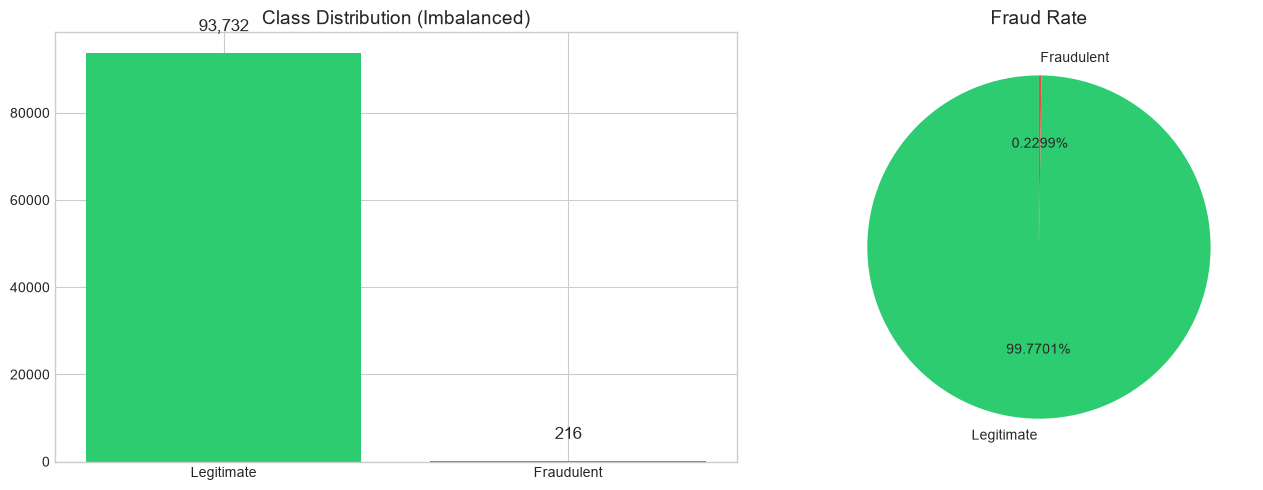

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values, color=colors)
axes[0].set_title('Class Distribution (Imbalanced)', fontsize=14)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=12)

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.4f%%', colors=colors, startangle=90)
axes[1].set_title('Fraud Rate', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/fraud_imbalance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: fraud_imbalance.png")
plt.show()

In [8]:
# ============================================
# PREPARE DATA - Handle NaN values
# ============================================

print("="*60)
print("CHECKING FOR NaN VALUES")
print("="*60)

# Check NaN in dataset
print(f"Total NaN in dataset: {df.isnull().sum().sum()}")
print(f"NaN in target column 'Class': {df['Class'].isnull().sum()}")

# Drop rows where target is NaN
if df['Class'].isnull().sum() > 0:
    df = df.dropna(subset=['Class'])
    print(f"✅ Dropped rows with NaN target. New shape: {df.shape}")

# Drop any remaining NaN in features
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print(f"✅ Dropped all rows with NaN. New shape: {df.shape}")
else:
    print("✅ No NaN values in features!")

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {len(X):,}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining: {X_train.shape[0]:,}")
print(f"Test: {X_test.shape[0]:,}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

CHECKING FOR NaN VALUES
Total NaN in dataset: 23
NaN in target column 'Class': 1
✅ Dropped rows with NaN target. New shape: (93948, 31)
✅ No NaN values in features!

Features: 30
Samples: 93,948

Training: 75,158
Test: 18,790
Train fraud rate: 0.2302%
Test fraud rate: 0.2288%


In [9]:
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("📊 LOGISTIC REGRESSION:")
print(f"   Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"   F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

📊 LOGISTIC REGRESSION:
   Precision: 0.0971
   Recall:    0.8605
   F1:        0.1745
   ROC-AUC:   0.9809


In [10]:
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("📊 RANDOM FOREST:")
print(f"   Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

📊 RANDOM FOREST:
   Precision: 0.8718
   Recall:    0.7907
   F1:        0.8293
   ROC-AUC:   0.9729


In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
}).round(4)

print(results.to_string(index=False))

              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.0971  0.8605    0.1745   0.9809
      Random Forest     0.8718  0.7907    0.8293   0.9729


✅ Saved: fraud_roc_curves.png


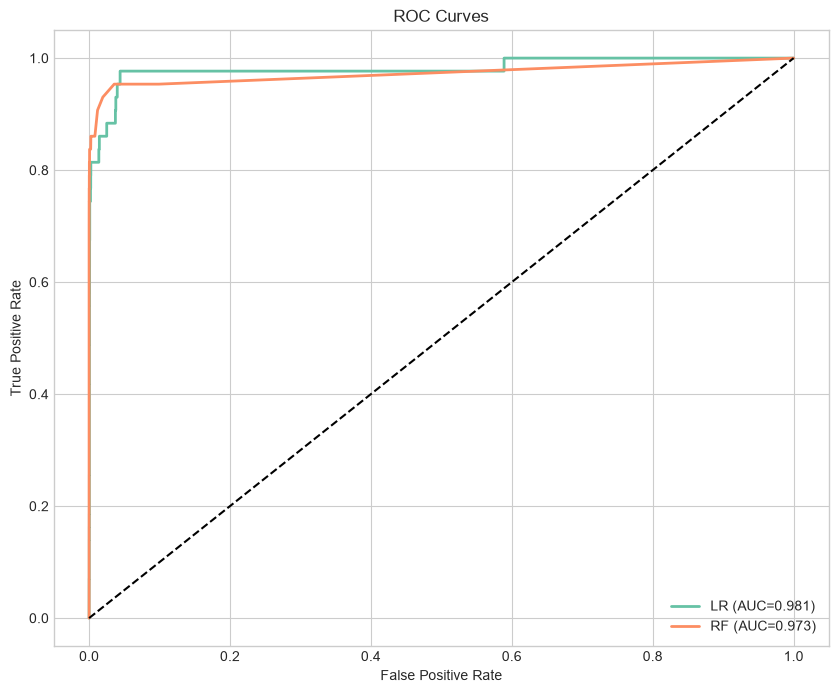

In [12]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig(OUTPUT_PATH + '/fraud_roc_curves.png', dpi=300, bbox_inches='tight')
print("✅ Saved: fraud_roc_curves.png")
plt.show()

✅ Saved: fraud_precision_recall.png


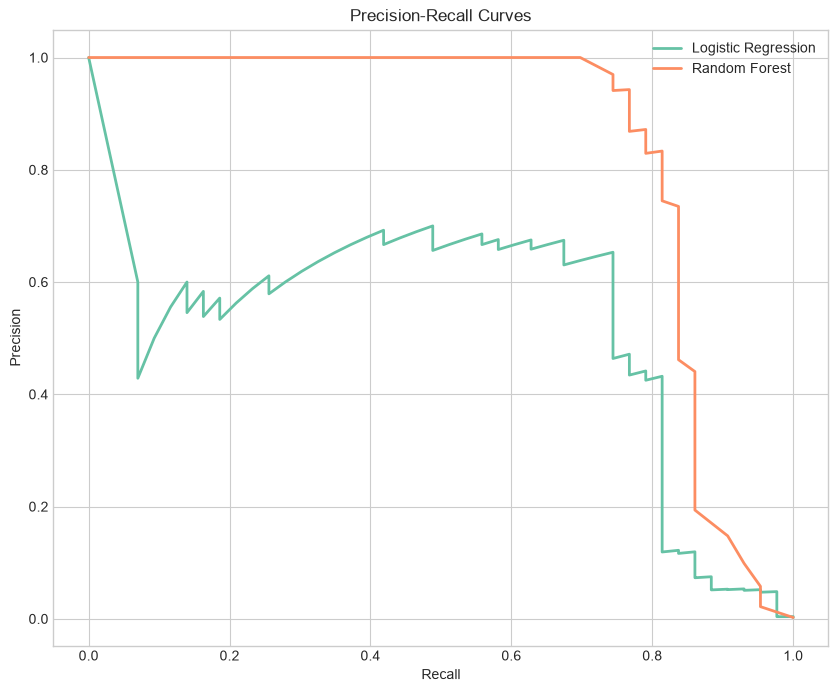

In [13]:
plt.figure(figsize=(10, 8))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label='Random Forest', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.savefig(OUTPUT_PATH + '/fraud_precision_recall.png', dpi=300, bbox_inches='tight')
print("✅ Saved: fraud_precision_recall.png")
plt.show()

✅ Saved: fraud_confusion_matrices.png


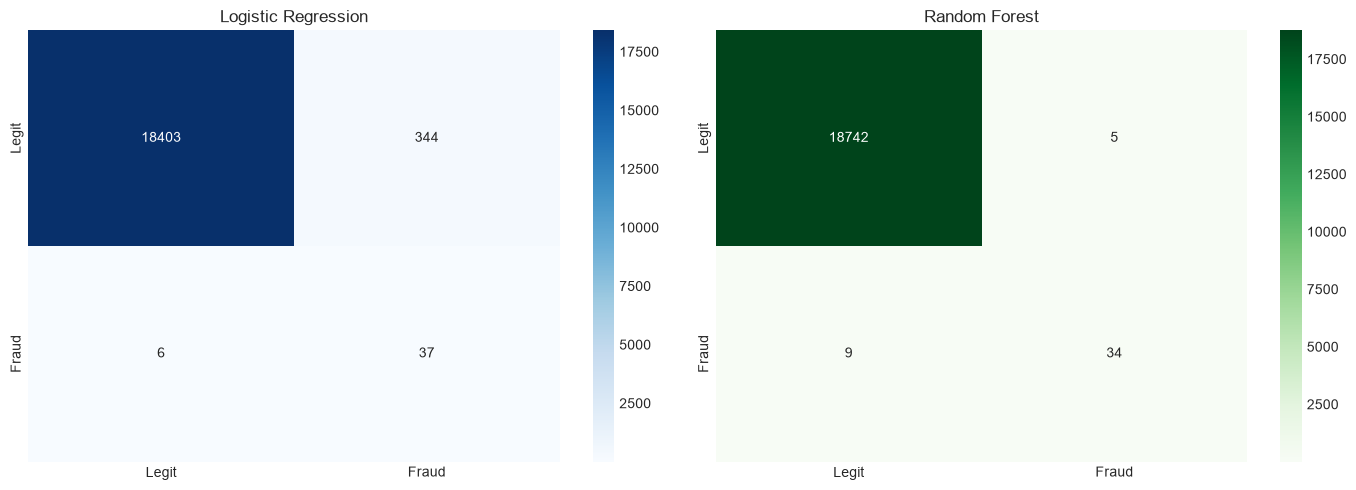

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0].set_title('Logistic Regression')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/fraud_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✅ Saved: fraud_confusion_matrices.png")
plt.show()

In [15]:
print("Tuning... This may take 2-3 minutes")

param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None]
}

rf_pipeline_tune = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf_pipeline_tune, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best ROC-AUC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print(f"\n📊 TUNED MODEL:")
print(f"   Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"   F1:        {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuning... This may take 2-3 minutes
✅ Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3}
✅ Best ROC-AUC: 0.9852

📊 TUNED MODEL:
   Precision: 0.7391
   Recall:    0.7907
   F1:        0.7640
   ROC-AUC:   0.9751


In [16]:
print("="*60)
print("✅ PROJECT 2 COMPLETE!")
print("="*60)

print("\n📁 Files saved to:")
print(f"   {OUTPUT_PATH}/fraud_imbalance.png")
print(f"   {OUTPUT_PATH}/fraud_roc_curves.png")
print(f"   {OUTPUT_PATH}/fraud_precision_recall.png")
print(f"   {OUTPUT_PATH}/fraud_confusion_matrices.png")

print("\n🎯 Project 2 done!")

✅ PROJECT 2 COMPLETE!

📁 Files saved to:
   C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/fraud_imbalance.png
   C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/fraud_roc_curves.png
   C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/fraud_precision_recall.png
   C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/fraud_confusion_matrices.png

🎯 Project 2 done!
